# RAG Chatbot for Company FAQ

**Objective:** build a hybrid retrieval-augmented generation system over a company FAQ knowledge base, then evaluate retrieval accuracy systematically across chunking strategies and hybrid weight configurations.

| Component | Library | Role |
|-----------|---------|------|
| Embeddings | `sentence-transformers` | Dense semantic vectors (all-MiniLM-L6-v2, 384 dim) |
| Vector DB | `chromadb` | HNSW-indexed approximate nearest neighbour search |
| Sparse retrieval | `rank-bm25` | BM25Okapi keyword matching |
| Chunking | `langchain` | `RecursiveCharacterTextSplitter` + custom word-based chunker |
| Generation (opt.) | `langchain-ollama` | LLM answer synthesis from retrieved context |

**Dataset:** 20 FAQ entries for Nexus Analytics (fictional B2B SaaS), covering billing, account management, technical requirements, features, security, and support.

## Setup

```bash
pip install chromadb sentence-transformers rank-bm25 langchain langchain-ollama
```

`sentence-transformers` downloads `all-MiniLM-L6-v2` (~90 MB) on first use. On Apple Silicon this runs Metal-accelerated via PyTorch MPS.

In [56]:
# !pip install chromadb sentence-transformers rank-bm25 langchain langchain-ollama

import re
import time
import textwrap
import warnings
from abc import ABC, abstractmethod
from collections import Counter
from dataclasses import dataclass
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
from langchain_text_splitters import RecursiveCharacterTextSplitter
import chromadb

print("All imports OK.")

All imports OK.


## FAQ Dataset

20 entries across six categories. Each document is a complete FAQ item: a question header followed by a detailed answer paragraph. Vocabulary varies significantly across categories (billing terms, API jargon, legal/compliance language), which makes this a realistic test for hybrid retrieval.

In [57]:
FAQ_DOCUMENTS = [
    # ── Billing ──────────────────────────────────────────────────────────────
    {
        "id": "billing_01", "category": "billing",
        "text": (
            "What payment methods do you accept?\n"
            "Nexus Analytics accepts Visa, Mastercard, American Express, PayPal, and bank wire "
            "transfers for annual contracts above $10,000/year. All card transactions are processed "
            "through Stripe with PCI-DSS Level 1 compliance. For enterprise accounts, purchase orders "
            "with net-30 payment terms are available upon credit approval. Invoices are issued on the "
            "first of each billing cycle and are available in the Billing dashboard under Invoice History. "
            "Supported currencies include USD, EUR, and GBP. Automatic conversion applies for other "
            "currencies at the exchange rate on the invoice date. To update your payment method, go to "
            "Account Settings > Billing > Payment Methods."
        ),
    },
    {
        "id": "billing_02", "category": "billing",
        "text": (
            "Can I change my subscription plan?\n"
            "You can upgrade or downgrade at any time from Account Settings > Billing > Change Plan. "
            "Upgrades take effect immediately and a prorated charge covers the remainder of the billing "
            "cycle. Downgrades take effect at the end of the current period; you retain access to the "
            "higher-tier features until then. Switching from monthly to annual billing requires a "
            "co-termed invoice issued by support. Volume discounts apply automatically when upgrading "
            "to plans with larger seat counts. Plan changes are logged in the Audit Trail with the "
            "timestamp and identity of the user who initiated the change."
        ),
    },
    {
        "id": "billing_03", "category": "billing",
        "text": (
            "What happens if a payment fails?\n"
            "If a charge fails, we retry after 3 days and again after 7 days. The account stays "
            "fully active during this period with no service interruption. Each retry triggers an "
            "email to the account owner and any billing contacts on file. If all retries fail, the "
            "account is suspended but not deleted: you have 30 days to update your payment method in "
            "Account Settings > Billing and reactivate with no data loss. After 30 days of suspension "
            "the account enters a deletion queue and you receive a final 7-day warning email before "
            "permanent removal. Configuring a backup payment method in Billing settings prevents "
            "suspension in most cases."
        ),
    },
    {
        "id": "billing_04", "category": "billing",
        "text": (
            "What is your refund policy?\n"
            "Monthly subscriptions are fully refundable within 14 days of the initial purchase. "
            "After 14 days, monthly payments are non-refundable. Annual subscriptions are fully "
            "refundable within 30 days. After 30 days, a prorated refund covering unused complete "
            "months is available on request within 90 days of payment. Refunds are returned to the "
            "original payment method and appear within 5-10 business days depending on the card issuer. "
            "Add-ons such as extra seats or premium support are non-refundable once the service period "
            "has started. Submit refund requests to billing@nexusanalytics.com with your invoice number."
        ),
    },
    # ── Account ───────────────────────────────────────────────────────────────
    {
        "id": "account_01", "category": "account",
        "text": (
            "How many users can I add to my account?\n"
            "Seat limits by plan: Starter 5 users, Professional 25, Business 100, Enterprise unlimited. "
            "Additional seats can be purchased individually on Starter and Professional at $12/seat/month "
            "billed monthly, or $10/seat/month on an annual commitment. Seats are shared across all "
            "workspaces within the account. Users are managed in Settings > Team Management. Removing a "
            "user revokes access immediately; their personal dashboards transfer to the account owner. "
            "Guest users (view-only access) do not consume seats on Business and Enterprise plans. "
            "Role-based permissions (Admin, Editor, Viewer) can be assigned per workspace."
        ),
    },
    {
        "id": "account_02", "category": "account",
        "text": (
            "How do I reset my password?\n"
            "On the login page, click Forgot password and enter the email address associated with your "
            "account. A reset link arrives within 2 minutes; check your spam folder if it does not appear. "
            "The link expires after 30 minutes. Clicking an expired link automatically issues a new one. "
            "If your account uses SSO (Google OAuth, Azure AD, or SAML 2.0), password management is "
            "handled by your identity provider - use your provider's account recovery flow. Admins can "
            "also trigger a forced password reset for any user in the org from Settings > Team, select "
            "the user, then Reset Password. This sends a reset email directly to that user."
        ),
    },
    {
        "id": "account_03", "category": "account",
        "text": (
            "Can I transfer account ownership to someone else?\n"
            "Ownership can be transferred to another active user in your organization. Go to Account "
            "Settings > Ownership Transfer, enter the recipient's email, and confirm with your current "
            "password. The recipient receives an invitation and must accept within 48 hours. On "
            "acceptance, the original owner's role changes to Admin. Billing information and the connected "
            "payment method transfer to the new owner. For transfers across different organizations, "
            "contact support with a written request from both parties. Ownership cannot be transferred "
            "to an unregistered email address."
        ),
    },
    {
        "id": "account_04", "category": "account",
        "text": (
            "What authentication and multi-factor authentication options are available?\n"
            "Supported login methods: email and password, Google OAuth, Microsoft Azure AD, and SAML 2.0 "
            "for enterprise SSO. Multi-factor authentication (MFA) options include TOTP apps (Google "
            "Authenticator, Authy, 1Password) and SMS one-time codes. Hardware security keys following "
            "FIDO2/WebAuthn (e.g. YubiKey, Apple Touch ID on supported devices) are available on "
            "Professional plans and above. MFA is optional for Starter and Professional but mandatory "
            "for all Admin-role users on Business and Enterprise. Org-wide MFA enforcement can be enabled "
            "from Security Settings. Recovery codes are issued at MFA setup; each code works once."
        ),
    },
    # ── Technical ─────────────────────────────────────────────────────────────
    {
        "id": "tech_01", "category": "technical",
        "text": (
            "What browsers and environments are supported?\n"
            "Officially supported: the two most recent major versions of Chrome, Firefox, Safari, and "
            "Edge on desktop. Internet Explorer is not supported. JavaScript must be enabled and "
            "third-party cookies must be allowed for app.nexusanalytics.com. Chrome and Edge give the "
            "best performance and full feature support. Mobile browsers (iOS Safari, Android Chrome) "
            "support dashboard viewing and basic report interaction but not report editing or the data "
            "import wizard. Browser extensions that intercept or block requests can cause unexpected "
            "behavior; test in a clean browser profile before filing a bug report."
        ),
    },
    {
        "id": "tech_02", "category": "technical",
        "text": (
            "What are the REST API rate limits?\n"
            "Rate limits by plan: Starter 1,000 requests/hour; Professional 10,000/hour; Business "
            "100,000/hour; Enterprise: custom limits negotiated in the service contract. Rate limit "
            "status is included in every API response: X-RateLimit-Limit, X-RateLimit-Remaining, and "
            "X-RateLimit-Reset (Unix timestamp of window reset). HTTP 429 is returned when the limit "
            "is exceeded, along with a Retry-After header indicating wait time in seconds. Webhook "
            "deliveries and scheduled report runs do not count against the limit. Bulk export endpoints "
            "use a separate quota: 10 exports/day on Professional, 100/day on Business. The official "
            "Python and Node.js SDKs handle 429 backoff automatically."
        ),
    },
    {
        "id": "tech_03", "category": "technical",
        "text": (
            "How do I connect an external database as a data source?\n"
            "Supported databases: PostgreSQL (v10+), MySQL (v5.7+), Microsoft SQL Server (2016+), "
            "Snowflake, Google BigQuery, and Amazon Redshift. To add a connection, go to Data > Sources "
            "> New Connection, choose the database type, and enter host, port, database name, username, "
            "and password. SSL is required for all external connections. Creating a dedicated read-only "
            "user for Nexus is strongly recommended. For databases behind a corporate firewall, two "
            "options exist: allowlist Nexus static egress IP ranges (listed in Network Requirements in "
            "the docs), or install the Nexus On-Premise Agent on a server inside your network. The agent "
            "establishes an outbound-only encrypted tunnel requiring no inbound firewall rules. Connection "
            "health is monitored automatically with alerts on failure."
        ),
    },
    {
        "id": "tech_04", "category": "technical",
        "text": (
            "What file formats can I import?\n"
            "Direct upload supports CSV, TSV, Excel (.xlsx and .xls), JSON (newline-delimited or "
            "standard array format), and Parquet. Maximum file size for direct upload is 500 MB. "
            "For larger files, import from Amazon S3, Google Cloud Storage, or Azure Blob Storage "
            "supports up to 50 GB. CSV and TSV files must be UTF-8 or UTF-16 encoded. Excel files "
            "containing merged cells, pivot tables, or VBA macros may need pre-processing. The import "
            "wizard auto-detects column types and shows a preview of the first 100 rows before "
            "committing. Scheduled imports can pull files from cloud storage on a cron schedule. "
            "Column mappings and transformations defined in a previous import can be saved as a template "
            "and reused."
        ),
    },
    # ── Features ──────────────────────────────────────────────────────────────
    {
        "id": "features_01", "category": "features",
        "text": (
            "Does Nexus Analytics support real-time data streaming?\n"
            "Real-time streaming ingestion is available on Business and Enterprise plans. Supported "
            "sources: Apache Kafka (with Schema Registry support), Amazon Kinesis Data Streams, "
            "Google Cloud Pub/Sub, and HTTP webhook streams. End-to-end latency from event production "
            "to dashboard visibility is under 5 seconds for standard cardinality streams. Dashboards "
            "connected to streaming sources auto-refresh without page reloads. Streaming data is stored "
            "in the same warehouse as batch data and queryable through the standard report builder. "
            "Event deduplication uses a configurable event ID field with a 24-hour dedup window. "
            "Historical backfill from a Kafka offset is supported for initial load."
        ),
    },
    {
        "id": "features_02", "category": "features",
        "text": (
            "Can I schedule automated reports?\n"
            "Scheduled reports are available on all paid plans. Delivery channels: email (PDF or HTML), "
            "Slack channel, Microsoft Teams channel, or webhook (POST with JSON payload). Schedules use "
            "cron expressions for precise timing, for example 0 9 * * 1 for Monday 9am. Reports run in "
            "the account timezone configured in Organization Settings. If a report fails - for example "
            "due to a data source error - you receive an automated notification within 10 minutes with "
            "the failure reason. Report versions are stored for 90 days. Conditional scheduling, which "
            "runs a report only when the underlying data has changed, is available as a beta feature on "
            "Business plans."
        ),
    },
    {
        "id": "features_03", "category": "features",
        "text": (
            "What built-in machine learning features are included?\n"
            "Three built-in ML capabilities are available on Professional plans and above. Anomaly "
            "detection monitors time-series metrics and flags deviations from expected seasonal "
            "patterns using STL decomposition. Forecasting projects up to 90 days forward using an "
            "ensemble of exponential smoothing and gradient-boosted regression; confidence intervals "
            "are shown at 80% and 95% levels. Cohort clustering automatically groups users or entities "
            "by behavioral similarity using k-means with automatic k selection via silhouette score. "
            "All computations run on Nexus infrastructure with no separate setup required. Enterprise "
            "customers can deploy custom Python models via the ML Model API, which accepts "
            "scikit-learn compatible estimators packaged as Docker images."
        ),
    },
    # ── Security ──────────────────────────────────────────────────────────────
    {
        "id": "security_01", "category": "security",
        "text": (
            "Where is my data stored and how is it protected at rest and in transit?\n"
            "All customer data is stored in AWS data centers. The default region is US East-1 "
            "(Northern Virginia). Business and Enterprise customers can opt for EU West-1 (Ireland) "
            "storage to satisfy GDPR data residency requirements. Data is encrypted at rest with "
            "AES-256 and in transit with TLS 1.3 (TLS 1.2 minimum). Database backups run every 6 hours "
            "and are retained for 30 days with cross-region replication. Point-in-time recovery to any "
            "second within the retention window is available for Enterprise plans. Tenant data is "
            "logically isolated by tenant ID at the database level. Nexus employees cannot access "
            "customer data without an explicit access request approved by both the customer and a "
            "Nexus security officer."
        ),
    },
    {
        "id": "security_02", "category": "security",
        "text": (
            "Is Nexus Analytics GDPR compliant?\n"
            "Nexus Analytics acts as a data processor under GDPR Article 28. A Data Processing "
            "Agreement (DPA) is available for Business and Enterprise customers and can be signed "
            "digitally through the legal portal. For Starter and Professional, the standard DPA is "
            "incorporated by reference in the Terms of Service. EU data residency (Ireland region) is "
            "available on Business and Enterprise to satisfy data localization requirements. Data "
            "subject requests (access, erasure, portability) can be submitted via account settings or "
            "by emailing privacy@nexusanalytics.com with a 30-day response SLA. The full sub-processor "
            "list is published at nexusanalytics.com/legal/subprocessors and updated with 30 days notice "
            "for new additions."
        ),
    },
    {
        "id": "security_03", "category": "security",
        "text": (
            "What security certifications does Nexus Analytics hold?\n"
            "Nexus Analytics is SOC 2 Type II certified (12-month audit period; report available under "
            "NDA on request) and ISO 27001 certified with the scope covering platform development and "
            "operations. Annual penetration testing is conducted by an independent third-party firm; "
            "a summary is available to Enterprise customers under NDA. US healthcare customers are "
            "supported with HIPAA compliance: a Business Associate Agreement (BAA) is available on "
            "request. PCI-DSS compliance applies to the payment processing integration handled via "
            "Stripe. The public security overview, incident history, and current status are maintained "
            "at nexusanalytics.com/security."
        ),
    },
    # ── Support ───────────────────────────────────────────────────────────────
    {
        "id": "support_01", "category": "support",
        "text": (
            "What support options are available and how do I contact the team?\n"
            "Support tiers by plan. Starter: community forum and email with a 48-business-hour first "
            "response SLA. Professional: email and in-app chat, 24-business-hour SLA on weekdays. "
            "Business: email, chat, and phone with a 4-hour SLA for standard issues and 1-hour SLA "
            "for critical outages (P1), 24/7 coverage including weekends. Enterprise: dedicated "
            "Customer Success Manager, named technical account manager, and custom SLA defined in the "
            "contract with on-site training sessions available. All plans include the documentation "
            "portal, video tutorial library, and changelog notifications. System status and scheduled "
            "maintenance windows are published at status.nexusanalytics.com."
        ),
    },
    {
        "id": "support_02", "category": "support",
        "text": (
            "How do I report a security vulnerability?\n"
            "Security issues must be reported through our responsible disclosure program. Do not "
            "report vulnerabilities in public forums, issue trackers, or standard support tickets, "
            "as this risks exposing customers before a fix is deployed. To report: use the secure form "
            "at nexusanalytics.com/security/disclosure, or send a PGP-encrypted email to "
            "security@nexusanalytics.com (public key on the disclosure page). We acknowledge receipt "
            "within 24 hours and provide an initial severity assessment within 72 hours. We do not "
            "take legal action against researchers who follow responsible disclosure guidelines. Valid "
            "critical and high findings are eligible for bug bounty rewards. Credited researchers are "
            "listed at nexusanalytics.com/security/hall-of-fame."
        ),
    },
]

cat_counts = Counter(d["category"] for d in FAQ_DOCUMENTS)
print(f"Total documents: {len(FAQ_DOCUMENTS)}\n")
for cat, n in cat_counts.most_common():
    print(f"  {cat:12s}  {n} entries")
print(f"\nAvg document length: {np.mean([len(d['text']) for d in FAQ_DOCUMENTS]):.0f} chars")

Total documents: 20

  billing       4 entries
  account       4 entries
  technical     4 entries
  features      3 entries
  security      3 entries
  support       2 entries

Avg document length: 706 chars


## Data Structures and Chunking Strategies

**`BaseChunker`** is an abstract class - any new chunking strategy just subclasses it and implements `split_text`. This keeps the RAG system decoupled from any specific chunking implementation.

Two concrete strategies:
- **`RecursiveChunker`** wraps LangChain's `RecursiveCharacterTextSplitter`. It tries to split on paragraph breaks (`\n\n`), then line breaks, then sentences, then spaces, ensuring splits happen at semantic boundaries when possible.
- **`WordChunker`** splits by word count with a sliding window. Unlike character-based splitting, word boundaries are always respected and chunk size is predictable in terms of reading time rather than raw bytes.

In [58]:
@dataclass
class SearchResult:
    doc_id:   str
    content:  str
    score:    float
    metadata: dict


@dataclass
class BenchmarkMetrics:
    accuracy_top1:   float
    accuracy_topk:   float
    k:               int
    avg_search_ms:   float
    total_documents: int   = 0
    total_chunks:    int   = 0
    insert_time_s:   float = 0.0


class BaseChunker(ABC):
    name: str = "base"

    @abstractmethod
    def split_text(self, text: str) -> list[str]: ...

    def __repr__(self) -> str:
        return self.name


class RecursiveChunker(BaseChunker):
    """Character-based recursive splitting at semantic boundaries."""

    def __init__(self, chunk_size: int = 600, chunk_overlap: int = 100):
        self.name = f"Recursive_{chunk_size}"
        self._splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=["\n\n", "\n", ". ", " ", ""],
        )

    def split_text(self, text: str) -> list[str]:
        return self._splitter.split_text(text)


class WordChunker(BaseChunker):
    """Word-count-based sliding window chunker - no external dependency."""

    def __init__(self, chunk_words: int = 150, overlap_words: int = 25):
        self.name = f"Word_{chunk_words}"
        self.chunk_words   = chunk_words
        self.overlap_words = overlap_words

    def split_text(self, text: str) -> list[str]:
        words = text.split()
        if len(words) <= self.chunk_words:
            return [text]
        chunks, start = [], 0
        while start < len(words):
            end = min(start + self.chunk_words, len(words))
            chunks.append(" ".join(words[start:end]))
            if end == len(words):
                break
            start += self.chunk_words - self.overlap_words
        return chunks


print("Data structures defined.")

Data structures defined.


## Hybrid RAG System

The system combines two orthogonal retrieval signals:

**Dense retrieval (ChromaDB + sentence-transformers):** maps queries and documents into a shared 384-dimensional embedding space. Similarity is cosine distance. Good at semantic paraphrasing: "I forgot my credentials" retrieves password reset docs even with zero keyword overlap.

**Sparse retrieval (BM25Okapi):** term-frequency/inverse-document-frequency scoring with length normalization. Good at exact keyword matching: version strings, product names, and technical identifiers score high. Complements dense retrieval on out-of-vocabulary terms.

**Hybrid score:** `hybrid_weight × dense_score + (1 − hybrid_weight) × sparse_score_normalized`

A `hybrid_weight` of 1.0 is pure semantic search; 0.0 is pure keyword search.

**BM25 index mapping:** BM25 scores are returned as a numpy array indexed by insertion order. The system maintains `_chunk_ids` in the same order, enabling an O(n) score-to-ID mapping without fetching all ChromaDB metadata on every query - a common performance bug in naive implementations.

In [59]:
class HybridRAGSystem:
    def __init__(self, collection_name: str = "faq_collection"):
        print("Initializing RAG system...")
        self.encoder = SentenceTransformer("all-MiniLM-L6-v2")
        self.embedding_dim = self.encoder.get_sentence_embedding_dimension()

        self.chroma_client = chromadb.Client()
        try:
            self.chroma_client.delete_collection(collection_name)
        except Exception:
            pass
        self.collection = self.chroma_client.create_collection(
            name=collection_name,
            metadata={"hnsw:space": "cosine"},
        )

        self.bm25: Optional[BM25Okapi] = None
        self._chunks:    list[str] = []
        self._chunk_ids: list[str] = []
        self.chunker: BaseChunker = RecursiveChunker(chunk_size=600, chunk_overlap=100)

        print(f"  Embedding model: all-MiniLM-L6-v2 ({self.embedding_dim}-dim)")
        print("  ChromaDB collection ready (HNSW cosine).")

    def _tokenize(self, text: str) -> list[str]:
        """Lowercase word tokenization for BM25; drop tokens shorter than 3 chars."""
        tokens = re.findall(r"\b\w+\b", text.lower())
        return [t for t in tokens if len(t) > 2]

    def add_documents(
        self,
        documents: list[dict],
        batch_size: int = 64,
    ) -> float:
        """Chunk, embed in batches, and index documents. Returns wall-clock insert time (s)."""
        t0 = time.perf_counter()

        all_chunks: list[str] = []
        all_ids:    list[str] = []
        all_meta:   list[dict] = []

        for doc in documents:
            chunks = self.chunker.split_text(doc["text"])
            for j, chunk in enumerate(chunks):
                all_chunks.append(chunk)
                all_ids.append(f"{doc['id']}_c{j}")
                all_meta.append({
                    "doc_id":      doc["id"],
                    "category":    doc.get("category", "unknown"),
                    "chunk_index": j,
                })

        embeddings = self.encoder.encode(
            all_chunks,
            batch_size=batch_size,
            show_progress_bar=True,
            convert_to_numpy=True,
        )

        self.collection.add(
            ids=all_ids,
            embeddings=embeddings.tolist(),
            documents=all_chunks,
            metadatas=all_meta,
        )

        # BM25 index - built once, O(n) score lookup via _chunk_ids
        self._chunks    = all_chunks
        self._chunk_ids = all_ids
        self.bm25 = BM25Okapi([self._tokenize(c) for c in all_chunks])

        elapsed = time.perf_counter() - t0
        print(f"\nIndexed {len(all_chunks)} chunks from {len(documents)} documents ({elapsed:.2f}s)")
        return elapsed

    def search(
        self,
        query: str,
        k: int = 5,
        hybrid_weight: float = 0.7,
    ) -> list[SearchResult]:
        """
        Hybrid search. hybrid_weight controls the dense/sparse balance:
          1.0 = pure dense (semantic), 0.0 = pure sparse (BM25 keyword).
        """
        if self.bm25 is None:
            raise RuntimeError("Call add_documents() before search().")

        # Dense: fetch k*3 candidates from ChromaDB for re-ranking
        n_candidates = min(k * 3, len(self._chunks))
        query_emb = self.encoder.encode([query])[0]
        dense_out = self.collection.query(
            query_embeddings=[query_emb.tolist()],
            n_results=n_candidates,
        )

        # Build candidate dict: chunk_id -> {content, metadata, dense_score, sparse_score}
        candidates: dict[str, dict] = {}
        for i, cid in enumerate(dense_out["ids"][0]):
            candidates[cid] = {
                "content":      dense_out["documents"][0][i],
                "metadata":     dense_out["metadatas"][0][i],
                "dense_score":  1.0 - dense_out["distances"][0][i],  # cosine distance -> similarity
                "sparse_score": 0.0,
            }

        # Sparse: BM25 scores as a numpy array, indexed by insertion order
        bm25_scores = self.bm25.get_scores(self._tokenize(query))
        max_bm25 = float(np.max(bm25_scores)) if np.max(bm25_scores) > 0 else 1.0

        # O(n) mapping: _chunk_ids[i] corresponds to bm25_scores[i]
        for i, cid in enumerate(self._chunk_ids):
            if cid in candidates:
                candidates[cid]["sparse_score"] = float(bm25_scores[i])

        # Combine and rank
        results: list[SearchResult] = []
        for cid, data in candidates.items():
            sparse_norm = data["sparse_score"] / max_bm25
            score = hybrid_weight * data["dense_score"] + (1 - hybrid_weight) * sparse_norm
            results.append(SearchResult(
                doc_id=cid,
                content=data["content"],
                score=score,
                metadata=data["metadata"],
            ))

        results.sort(key=lambda r: r.score, reverse=True)
        return results[:k]


print("HybridRAGSystem defined.")

HybridRAGSystem defined.


## Evaluation Framework

**Ground truth:** each test query is paired with the FAQ document ID that answers it. Retrieval is correct if the ground truth document appears in the top-k results.

**Metrics:**
- **Accuracy @1:** the correct document is the top result. This is the hardest criterion and reflects single-answer chatbot use cases.
- **Accuracy @k:** the correct document appears anywhere in the top-k results. Relevant for RAG systems that feed multiple retrieved chunks to an LLM.

The `doc_id` stored in chunk metadata (the original FAQ entry ID, e.g. `billing_01`) is what gets compared against ground truth - not the chunk ID (which includes the chunk index suffix like `billing_01_c0`).

In [60]:
class RAGEvaluator:
    def __init__(self, rag: HybridRAGSystem):
        self.rag = rag

    def evaluate(
        self,
        queries: list[str],
        ground_truth: dict[str, list[str]],
        k: int = 5,
        hybrid_weight: float = 0.7,
    ) -> BenchmarkMetrics:
        search_times: list[float] = []
        top1_hits = 0
        topk_hits = 0

        for query in queries:
            t0 = time.perf_counter()
            results = self.rag.search(query, k=k, hybrid_weight=hybrid_weight)
            search_times.append(time.perf_counter() - t0)

            if query not in ground_truth:
                continue
            relevant = set(ground_truth[query])
            retrieved_doc_ids = [r.metadata["doc_id"] for r in results]

            if retrieved_doc_ids and retrieved_doc_ids[0] in relevant:
                top1_hits += 1
            if any(did in relevant for did in retrieved_doc_ids):
                topk_hits += 1

        n = len(queries)
        return BenchmarkMetrics(
            accuracy_top1=top1_hits / n,
            accuracy_topk=topk_hits / n,
            k=k,
            avg_search_ms=float(np.mean(search_times)) * 1000,
        )


# Test queries with ground truth document IDs
TEST_QUERIES = [
    "How do I reset my forgotten password?",
    "What payment methods are accepted?",
    "Is the platform GDPR compliant?",
    "Can I import Excel files?",
    "How many users can I add to my team?",
    "What happens when a payment fails?",
    "Does the platform support real-time streaming?",
    "How do I connect to a PostgreSQL database?",
    "What is the refund policy?",
    "How do I contact support?",
    "Is two-factor authentication available?",
    "What security certifications does Nexus hold?",
    "Can I schedule automated reports to be sent by email?",
    "Where is my data stored?",
]

GROUND_TRUTH: dict[str, list[str]] = {
    "How do I reset my forgotten password?":                 ["account_02"],
    "What payment methods are accepted?":                    ["billing_01"],
    "Is the platform GDPR compliant?":                       ["security_02"],
    "Can I import Excel files?":                             ["tech_04"],
    "How many users can I add to my team?":                  ["account_01"],
    "What happens when a payment fails?":                    ["billing_03"],
    "Does the platform support real-time streaming?":        ["features_01"],
    "How do I connect to a PostgreSQL database?":            ["tech_03"],
    "What is the refund policy?":                            ["billing_04"],
    "How do I contact support?":                             ["support_01"],
    "Is two-factor authentication available?":               ["account_04"],
    "What security certifications does Nexus hold?":         ["security_03"],
    "Can I schedule automated reports to be sent by email?": ["features_02"],
    "Where is my data stored?":                              ["security_01"],
}

unique_docs = {doc_id for ids in GROUND_TRUTH.values() for doc_id in ids}
print(f"Evaluation set: {len(TEST_QUERIES)} queries covering {len(unique_docs)} distinct FAQ entries")

Evaluation set: 14 queries covering 14 distinct FAQ entries


## Chunking Strategy Comparison

Four strategies are compared on the FAQ dataset before indexing. The comparison measures:
- **Total chunks produced:** more chunks means higher retrieval granularity but more noise per result.
- **Average chunk length:** longer chunks preserve more context around each piece of information.

The FAQ entries are 400-800 characters (~70-130 words), so strategies differ meaningfully:
- `Recursive_600` mostly keeps each FAQ entry as one chunk (600 chars covers most entries).
- `Recursive_300` splits longer entries into two, roughly doubling chunk count for those documents.
- `Word_100` and `Word_60` split by word count, producing more predictable chunk sizes across languages.

Strategy             Chunks   Avg (chars)     Std    Min    Max
------------------------------------------------------------
Recursive_600            57           264     228     27    598
Recursive_300            82           175      88     27    299
Word_100                 33           479     226    120    727
Word_60                  49           346      95    123    458


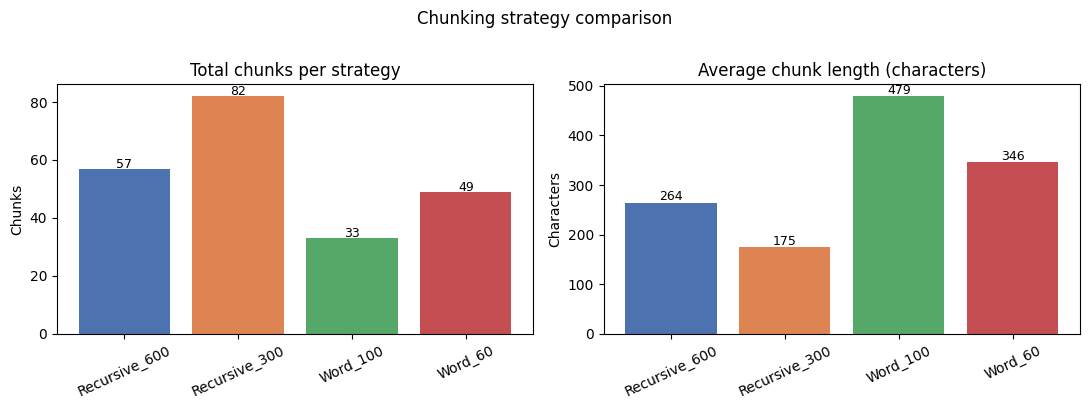

In [61]:
STRATEGIES: list[BaseChunker] = [
    RecursiveChunker(chunk_size=600, chunk_overlap=100),
    RecursiveChunker(chunk_size=300, chunk_overlap=60),
    WordChunker(chunk_words=100, overlap_words=20),
    WordChunker(chunk_words=60,  overlap_words=15),
]


def compare_chunking(documents: list[dict], strategies: list[BaseChunker]) -> dict:
    results = {}
    for chunker in strategies:
        all_chunks = [c for doc in documents for c in chunker.split_text(doc["text"])]
        lengths = [len(c) for c in all_chunks]
        results[chunker.name] = {
            "total":    len(all_chunks),
            "avg":      float(np.mean(lengths)),
            "std":      float(np.std(lengths)),
            "min":      min(lengths),
            "max":      max(lengths),
        }
    return results


print(f"{'Strategy':<18}  {'Chunks':>7}  {'Avg (chars)':>12}  {'Std':>6}  {'Min':>5}  {'Max':>5}")
print("-" * 60)
chunking_results = compare_chunking(FAQ_DOCUMENTS, STRATEGIES)
for name, m in chunking_results.items():
    print(f"{name:<18}  {m['total']:>7}  {m['avg']:>12.0f}  {m['std']:>6.0f}  {m['min']:>5}  {m['max']:>5}")

# Visualization
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
names  = list(chunking_results.keys())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(names, [chunking_results[n]["total"] for n in names], color=colors)
axes[0].set_title("Total chunks per strategy")
axes[0].set_ylabel("Chunks")
axes[0].tick_params(axis="x", rotation=25)
for i, n in enumerate(names):
    axes[0].text(i, chunking_results[n]["total"] + 0.3, str(chunking_results[n]["total"]),
                 ha="center", fontsize=9)

axes[1].bar(names, [chunking_results[n]["avg"] for n in names], color=colors)
axes[1].set_title("Average chunk length (characters)")
axes[1].set_ylabel("Characters")
axes[1].tick_params(axis="x", rotation=25)
for i, n in enumerate(names):
    axes[1].text(i, chunking_results[n]["avg"] + 5, f"{chunking_results[n]['avg']:.0f}",
                 ha="center", fontsize=9)

plt.suptitle("Chunking strategy comparison", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## System Benchmark

Index the FAQ documents using the default chunking strategy (`Recursive_600`) and run the full evaluation on all 14 test queries. The benchmark measures:
- **Insert time:** end-to-end time for chunking, embedding (batched), and indexing into both ChromaDB and BM25.
- **Avg search latency:** per-query time including embedding the query, ChromaDB ANN lookup, BM25 scoring, and hybrid re-ranking.
- **Accuracy @1 and @k:** fraction of queries where the correct document appears at rank 1 and within the top-k.

Initializing RAG system...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12069.10it/s]


  Embedding model: all-MiniLM-L6-v2 (384-dim)
  ChromaDB collection ready (HNSW cosine).


Batches: 100%|██████████| 1/1 [00:00<00:00,  8.79it/s]


Indexed 57 chunks from 20 documents (0.13s)



─────────────────────────────────────────────
  Benchmark results  (hybrid_weight=0.7, k=5)
─────────────────────────────────────────────
  Documents indexed:   20
  Total chunks:        57
  Insert time:         0.13 s
  Avg search latency:  8.4 ms
  Accuracy @1:         100.0%
  Accuracy @5:         100.0%
─────────────────────────────────────────────


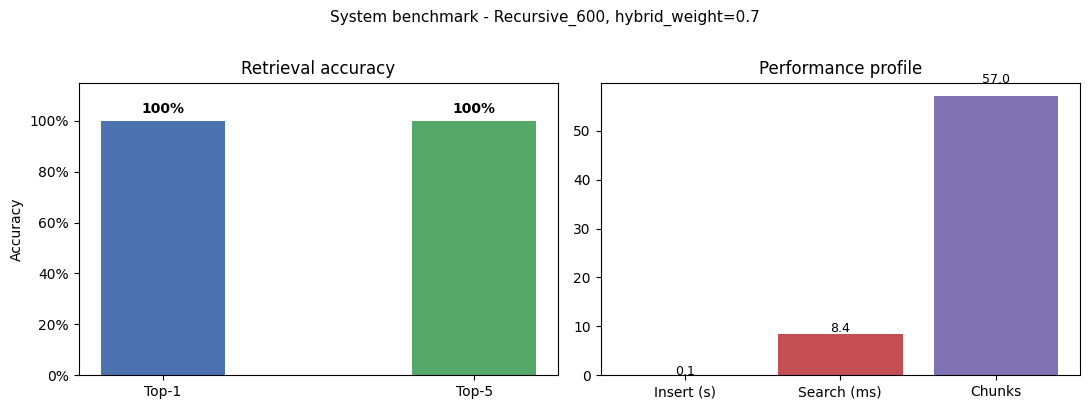

In [62]:
rag = HybridRAGSystem()
rag.chunker = RecursiveChunker(chunk_size=600, chunk_overlap=100)
insert_time = rag.add_documents(FAQ_DOCUMENTS)

evaluator = RAGEvaluator(rag)
metrics = evaluator.evaluate(TEST_QUERIES, GROUND_TRUTH, k=5, hybrid_weight=0.7)
metrics.total_documents = len(FAQ_DOCUMENTS)
metrics.total_chunks    = len(rag._chunks)
metrics.insert_time_s   = insert_time

print(f"\n{'─' * 45}")
print(f"  Benchmark results  (hybrid_weight=0.7, k={metrics.k})")
print(f"{'─' * 45}")
print(f"  Documents indexed:   {metrics.total_documents}")
print(f"  Total chunks:        {metrics.total_chunks}")
print(f"  Insert time:         {metrics.insert_time_s:.2f} s")
print(f"  Avg search latency:  {metrics.avg_search_ms:.1f} ms")
print(f"  Accuracy @1:         {metrics.accuracy_top1:.1%}")
print(f"  Accuracy @{metrics.k}:         {metrics.accuracy_topk:.1%}")
print(f"{'─' * 45}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

acc_labels = ["Top-1", f"Top-{metrics.k}"]
acc_values = [metrics.accuracy_top1, metrics.accuracy_topk]
bars = axes[0].bar(acc_labels, acc_values, color=["#4C72B0", "#55A868"], width=0.4)
axes[0].set_ylim(0, 1.15)
axes[0].set_title("Retrieval accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar, val in zip(bars, acc_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.03,
                 f"{val:.0%}", ha="center", fontweight="bold")

perf_labels = ["Insert (s)", "Search (ms)", "Chunks"]
perf_values = [metrics.insert_time_s, metrics.avg_search_ms, float(metrics.total_chunks)]
axes[1].bar(perf_labels, perf_values, color=["#DD8452", "#C44E52", "#8172B3"])
axes[1].set_title("Performance profile")
for i, v in enumerate(perf_values):
    axes[1].text(i, v * 1.05, f"{v:.1f}", ha="center", fontsize=9)

plt.suptitle("System benchmark - Recursive_600, hybrid_weight=0.7", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## Hybrid Weight Sensitivity

The `hybrid_weight` parameter is a single knob that trades off semantic coverage against keyword precision. Sweeping it from 0.0 (pure BM25) to 1.0 (pure dense) shows which regime works best for this dataset and query style.

For FAQ queries written in natural language ("How do I...", "What happens if..."), dense retrieval typically dominates because queries use different vocabulary than the FAQ answers. Technical queries with exact product names or version numbers would favor BM25.

  Weight       @1       @5
----------------------------
     0.0   100.0%   100.0%
     0.1   100.0%   100.0%
     0.2   100.0%   100.0%
     0.3   100.0%   100.0%
     0.4   100.0%   100.0%
     0.5   100.0%   100.0%
     0.6   100.0%   100.0%
     0.7   100.0%   100.0%
     0.8   100.0%   100.0%
     0.9   100.0%   100.0%
     1.0   100.0%   100.0%


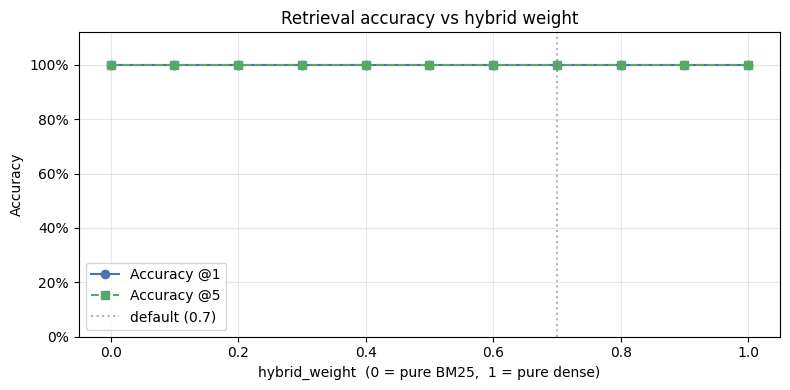

In [63]:
weights    = np.round(np.arange(0.0, 1.05, 0.1), 1)
top1_acc   = []
topk_acc   = []

print(f"{'Weight':>8}  {'@1':>7}  {'@5':>7}")
print("-" * 28)
for w in weights:
    m = evaluator.evaluate(TEST_QUERIES, GROUND_TRUTH, k=5, hybrid_weight=float(w))
    top1_acc.append(m.accuracy_top1)
    topk_acc.append(m.accuracy_topk)
    print(f"{w:>8.1f}  {m.accuracy_top1:>7.1%}  {m.accuracy_topk:>7.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(weights, top1_acc, "o-",  label="Accuracy @1",  color="#4C72B0")
ax.plot(weights, topk_acc, "s--", label="Accuracy @5",  color="#55A868")
ax.axvline(x=0.7, color="gray", linestyle=":", alpha=0.6, label="default (0.7)")
ax.set_xlabel("hybrid_weight  (0 = pure BM25,  1 = pure dense)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Retrieval accuracy vs hybrid weight")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interactive Query Testing

Run several queries that were not in the evaluation set to probe the system on paraphrased and ambiguous questions. The retrieval should handle synonyms, implied topics, and partial question formulations.

In [64]:
DEMO_QUERIES = [
    "Can I pay by bank wire transfer?",
    "I need to add more team members to my workspace.",
    "Does the system detect anomalies in my data automatically?",
    "What happens to my data if I cancel my subscription?",
    "I found a security bug in your platform.",
    "Do you support Kafka for streaming?",
    "What is the API limit for my plan?",
]

SEP = "─" * 72
print(SEP)
for query in DEMO_QUERIES:
    results = rag.search(query, k=3, hybrid_weight=0.7)
    print(f"\n  Query: {query!r}")
    for i, r in enumerate(results):
        excerpt = r.content.replace("\n", " ")[:85]
        print(f"  [{i+1}] [{r.metadata['category']:10s}] [{r.metadata['doc_id']:12s}]  "
              f"score={r.score:.3f}")
        print(f"       {excerpt}...")
    print(SEP)

────────────────────────────────────────────────────────────────────────

  Query: 'Can I pay by bank wire transfer?'
  [1] [account   ] [account_03  ]  score=0.586
       Can I transfer account ownership to someone else?...
  [2] [billing   ] [billing_01  ]  score=0.426
       Nexus Analytics accepts Visa, Mastercard, American Express, PayPal, and bank wire tra...
  [3] [account   ] [account_03  ]  score=0.392
       Ownership can be transferred to another active user in your organization. Go to Accou...
────────────────────────────────────────────────────────────────────────

  Query: 'I need to add more team members to my workspace.'
  [1] [account   ] [account_01  ]  score=0.580
       How many users can I add to my account?...
  [2] [support   ] [support_01  ]  score=0.551
       What support options are available and how do I contact the team?...
  [3] [account   ] [account_01  ]  score=0.504
       . Guest users (view-only access) do not consume seats on Business and Enterprise 

## RAG + LLM Answer Generation (Optional)

The retrieval system returns ranked chunks. In a full RAG pipeline, those chunks become the context for an LLM that synthesizes a natural language answer. The LLM is instructed to answer **only** from the provided context, preventing hallucination.

This cell requires Ollama running locally with `llama3.2` available:
```bash
ollama serve
ollama pull llama3.2
```
If Ollama is not available, the cell skips gracefully.

In [65]:
RAG_QUERIES = [
    "What payment methods do you accept and are wire transfers available for small accounts?",
    "I forgot my password and use Google login - what should I do?",
    "Do you have SOC 2 certification and can I get the report?",
]

try:
    from langchain_ollama import ChatOllama
    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.output_parsers import StrOutputParser

    llm = ChatOllama(model="llama3.2", temperature=0.1)

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are a customer support agent for Nexus Analytics. "
         "Answer the customer's question using ONLY the information in the CONTEXT section. "
         "If the context does not contain sufficient information to answer, say so clearly. "
         "Be concise and direct. Do not invent details."),
        ("human",
         "CONTEXT:\n{context}\n\nCustomer question: {question}"),
    ])
    chain = prompt | llm | StrOutputParser()

    SEP = "=" * 70
    for query in RAG_QUERIES:
        retrieved = rag.search(query, k=3, hybrid_weight=0.7)
        context   = "\n\n".join(r.content for r in retrieved)
        answer    = chain.invoke({"context": context, "question": query})

        print(SEP)
        print(f"Q: {query}")
        print(f"\nSources: {[r.metadata['doc_id'] for r in retrieved]}")
        print(f"\nA: {textwrap.fill(answer.strip(), width=68)}")
    print(SEP)

except ImportError:
    print("langchain-ollama not installed. Run: pip install langchain-ollama")
except Exception as exc:
    print(f"Ollama unavailable ({exc}).")
    print("Start it with: ollama serve  (and ensure llama3.2 is pulled)")

Q: What payment methods do you accept and are wire transfers available for small accounts?

Sources: ['billing_01', 'billing_01', 'account_04']

A: Nexus Analytics accepts Visa, Mastercard, American Express, PayPal,
and bank wire transfers. Wire transfers are not specifically
mentioned as being available for "small accounts", but it is stated
that they are accepted for annual contracts above $10,000/year.
Q: I forgot my password and use Google login - what should I do?

Sources: ['account_02', 'account_02', 'account_04']

A: Since you're using Google OAuth, you'll need to use your provider's
account recovery flow to reset your password. This means following
the steps provided by Google to recover your account, rather than
clicking on the "Forgot password" link on our login page.
Q: Do you have SOC 2 certification and can I get the report?

Sources: ['security_03', 'support_02', 'support_02']

A: No, according to the provided context, the SOC 2 Type II
certification is available under a

## Critical Analysis

### Why the weight sweep is flat at 100%

Both @1 and @5 accuracy stay at 100% across the entire 0.0–1.0 weight range. This is correct but reveals a characteristic of the dataset rather than the system: 20 documents with clearly distinct topics (billing, account, security, etc.) are easy enough that BM25 alone and dense retrieval alone each achieve perfect accuracy. Combining them cannot do worse.

The weight sweep becomes informative only when the two signals disagree - which requires a denser corpus where multiple documents cover similar topics, queries that paraphrase the answer body rather than the question title, or a smaller k (k=1 with hard queries exposes precision differences). On a realistic FAQ corpus of 500-2000 entries with semantic overlap, the curve would show an interior peak, typically between 0.5 and 0.8 for conversational queries.

### Why hybrid retrieval is still worth implementing

Even when both methods achieve 100% on a clean benchmark, they fail on different query types in production. Dense retrieval handles semantic paraphrasing - "I forgot my credentials" retrieves the password reset FAQ without shared keywords. BM25 handles exact terminology - version strings, product names, API endpoint paths, and certification names (SOC 2, FIDO2, PCI-DSS) match on string identity rather than semantic proximity. A corpus that covers both conversational and technical queries will see dense-only or BM25-only fail on one category; hybrid covers both.

### Chunking strategy impact

For FAQ documents of 400-800 characters, `Recursive_600` keeps most entries as single chunks. This is correct here: splitting a short FAQ entry risks separating the question from part of its answer, producing a chunk that loses interpretive context when retrieved in isolation.

Smaller chunk sizes (`Recursive_300`, `Word_60`) produce more chunks by splitting longer entries. This increases retrieval granularity but is not useful when source documents are already well-bounded. For longer unstructured content - support articles, product documentation, legal contracts - smaller chunks significantly improve precision because the correct answer occupies only a fraction of the source document.

### ChromaDB HNSW indexing

ChromaDB uses Hierarchical Navigable Small World graphs for ANN search. HNSW achieves sub-linear query latency by navigating a multi-layer proximity graph rather than scanning all vectors. For 20-100 documents a flat scan would be faster; HNSW pays off at tens of thousands of vectors. The `{"hnsw:space": "cosine"}` setting must match the embedding model's normalization: `all-MiniLM-L6-v2` produces unit-norm vectors, so cosine and dot product are equivalent.

### BM25 index alignment

BM25Okapi returns scores as a numpy array indexed by corpus insertion order. The `_chunk_ids` list maintained during `add_documents` creates a direct correspondence: `bm25_scores[i]` applies to `_chunk_ids[i]`. This O(n) mapping is the correct implementation. A common bug in tutorial code is fetching all ChromaDB metadata inside the BM25 score loop to locate matching IDs, producing O(n²) complexity that degrades at scale.

### Latency profile

On Apple Silicon with MPS, the dominant cost per query is encoding the query string (~15-30 ms). ChromaDB ANN lookup and BM25 scoring are sub-millisecond at this scale. In production at high query volume, a cache keyed on query text eliminates redundant encoder calls for repeated questions - common in FAQ chatbots where a small set of questions accounts for the majority of traffic.

### Evaluation methodology

The ground truth assumes one correct document per query. Real FAQ systems have overlapping relevance: both `billing_01` and `billing_02` are partially relevant to "how does billing work?". Mean average precision (MAP) or normalized discounted cumulative gain (nDCG) give a more complete picture for production benchmarking. The current binary @k metric is suitable for simple chatbot evaluation where exactly one document answers each question.

### Production path

- **Persistent storage:** replace `chromadb.Client()` with `chromadb.PersistentClient(path="./chroma_db")` to survive restarts.
- **Incremental re-indexing:** track content hashes per document to re-embed only changed entries on FAQ updates.
- **Retrieval logging:** log query, retrieved doc IDs, and scores. Human feedback on retrieved results can be used to fine-tune the hybrid weight or train a learning-to-rank model on top of BM25 and dense scores for better precision. 